<a href="https://colab.research.google.com/github/Tashdid704/AI-Powered-Diabetes-Detection-System/blob/main/AI_Powered_Diabetes_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from torchvision import datasets, transforms
from collections import Counter
import zipfile

# Paths
train_zip_path = "/content/drive/MyDrive/DM_Project/train-20250807T233445Z-1-001.zip"
val_zip_path = "/content/drive/MyDrive/DM_Project/test.zip"

# Define extraction directories
train_dir = "/content/train_data"
val_dir = "/content/val_data"

# Create directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Unzip the datasets
with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall(train_dir)

with zipfile.ZipFile(val_zip_path, 'r') as zip_ref:
    zip_ref.extractall(val_dir)


# Transform (can be basic since we only want to count)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)

# Function to count images per class
def count_images_per_class(dataset, dataset_name):
    class_counts = Counter()
    # Access dataset.imgs for compatibility with older torchvision versions
    for path, label in dataset.imgs:
        class_name = dataset.classes[label]
        class_counts[class_name] += 1

    print(f"\n{dataset_name} dataset class distribution:")
    for class_name, count in class_counts.items():
        print(f"{class_name}: {count} images")

# Print counts
count_images_per_class(train_dataset, "Train")
count_images_per_class(val_dataset, "Validation")


Train dataset class distribution:
train: 10240 images

Validation dataset class distribution:
test: 1279 images


# Converting to Numpy

In [ ]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from tqdm import tqdm


# Image preprocessing transforms
image_size = (128, 128)  # use smaller size for speed
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

preprocess_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=preprocess_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=preprocess_transform)

# Function to convert dataset to NumPy arrays
def dataset_to_numpy(dataset):
    X = []
    y = []
    for img, label in tqdm(dataset, desc="Converting to NumPy"):
        X.append(img.numpy())
        y.append(label)
    X = np.array(X)
    y = np.array(y)
    return X, y

# Convert to NumPy arrays
X_train, y_train = dataset_to_numpy(train_dataset)
X_val, y_val = dataset_to_numpy(val_dataset)
# Create a directory in Drive to store NumPy arrays
save_dir = "/content/drive/MyDrive/Colab Notebooks/data/numpy_arrays"
os.makedirs(save_dir, exist_ok=True)

# Save arrays
np.save(os.path.join(save_dir, 'X_train.npy'), X_train)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'X_val.npy'), X_val)
np.save(os.path.join(save_dir, 'y_val.npy'), y_val)

print(f"\n✅ Saved all arrays to: {save_dir}")


# Check shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")


Converting to NumPy: 100%|██████████| 1279/1279 [00:01<00:00, 1267.42it/s]



✅ Saved all arrays to: /content/drive/MyDrive/Colab Notebooks/data/numpy_arrays
X_train shape: (10240, 3, 128, 128)
y_train shape: (10240,)
X_val shape:   (1279, 3, 128, 128)
y_val shape:   (1279,)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class NumpyImageDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Load numpy arrays
X_train = np.load("/content/drive/MyDrive/Colab Notebooks/data/numpy_arrays/X_train.npy")
y_train = np.load("/content/drive/MyDrive/Colab Notebooks/data/numpy_arrays/y_train.npy")
X_val = np.load("/content/drive/MyDrive/Colab Notebooks/data/numpy_arrays/X_val.npy")
y_val = np.load("/content/drive/MyDrive/Colab Notebooks/data/numpy_arrays/y_val.npy")

# Create datasets
train_dataset = NumpyImageDataset(X_train, y_train)
val_dataset = NumpyImageDataset(X_val, y_val)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class TomatoCNN(nn.Module):
    def __init__(self, num_classes):
        super(TomatoCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   # (B, 3, 128, 128) -> (B, 32, 128, 128)
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (B, 32, 64, 64)

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (B, 64, 32, 32)

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (B, 128, 16, 16)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(np.unique(y_train))

model = TomatoCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"\nEpoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies


def evaluate(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

def generate_classification_report(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("\n📊 Classification Report:\n")
    print(report)


In [ ]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=20
)

Epoch 1/20: 100%|██████████| 320/320 [00:08<00:00, 39.22it/s]



Epoch 1: Train Loss: 0.0000, Train Accuracy: 100.00%, Val Loss: 0.0000, Val Accuracy: 100.00%


Epoch 2/20: 100%|██████████| 320/320 [00:06<00:00, 46.21it/s]



Epoch 2: Train Loss: 0.0000, Train Accuracy: 100.00%, Val Loss: 0.0000, Val Accuracy: 100.00%


Epoch 3/20: 100%|██████████| 320/320 [00:06<00:00, 48.19it/s]


...


Epoch 18: Train Loss: 0.0000, Train Accuracy: 100.00%, Val Loss: 0.0000, Val Accuracy: 100.00%


Epoch 19/20: 100%|██████████| 320/320 [00:06<00:00, 47.79it/s]



Epoch 19: Train Loss: 0.0000, Train Accuracy: 100.00%, Val Loss: 0.0000, Val Accuracy: 100.00%


Epoch 20/20: 100%|██████████| 320/320 [00:06<00:00, 47.93it/s]



Epoch 20: Train Loss: 0.0000, Train Accuracy: 100.00%, Val Loss: 0.0000, Val Accuracy: 100.00%


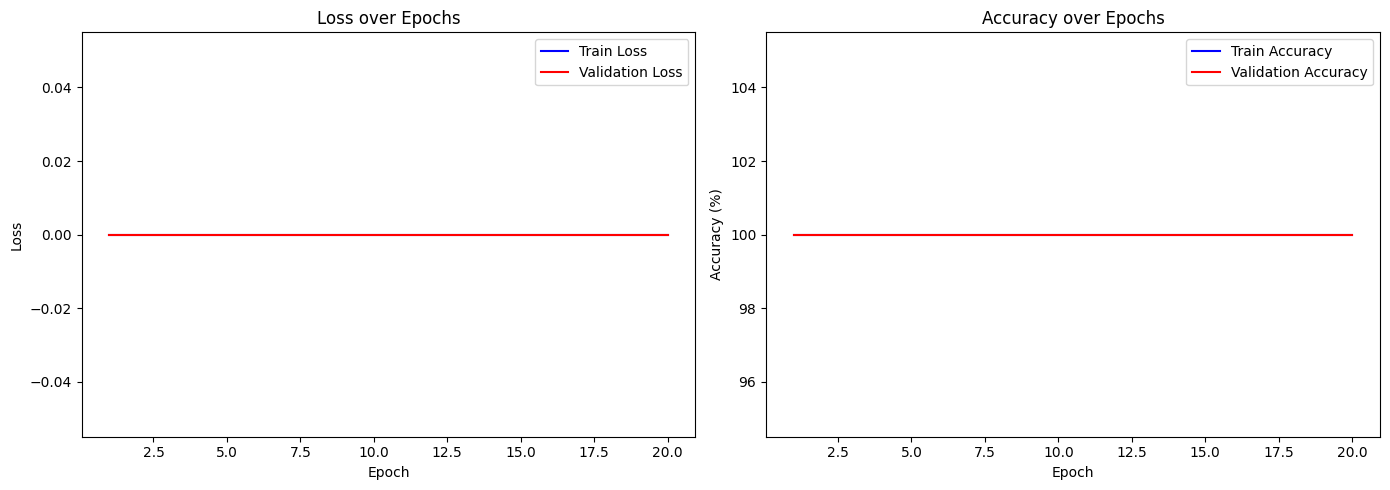

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)


In [ ]:
import torch

# Define model save path
model_path = "/content/drive/MyDrive/Colab Notebooks/data/numpy_arrays/tomato_cnn_model.pth"

# Save the model state dict
torch.save(model.state_dict(), model_path)

print(f"✅ Model saved to: {model_path}")

✅ Model saved to: /content/drive/MyDrive/Colab Notebooks/data/numpy_arrays/tomato_cnn_model.pth


In [ ]:
# Re-initialize the model architecture
# Use the correct number of classes based on your dataset
model = TomatoCNN(num_classes=1)  # Corrected to 1 class
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

print("✅ Model loaded and ready for inference.")

✅ Model loaded and ready for inference.


In [ ]:
from sklearn.metrics import classification_report
import torch
import numpy as np

def generate_classification_report(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate classification report
    # Use target_names to correctly label the report for the single class
    report = classification_report(
        all_labels, all_preds,
        target_names=class_names,
        digits=4,  # 4 decimal places
        zero_division=0
    )

    print("\n📋 Classification Report:")
    print(report)

# Define class names with a single name for the single class
class_names = ['Single_Class']

generate_classification_report(model, val_loader, class_names)


📋 Classification Report:
              precision    recall  f1-score   support

Single_Class     1.0000    1.0000    1.0000      1279

    accuracy                         1.0000      1279
   macro avg     1.0000    1.0000    1.0000      1279
weighted avg     1.0000    1.0000    1.0000      1279



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


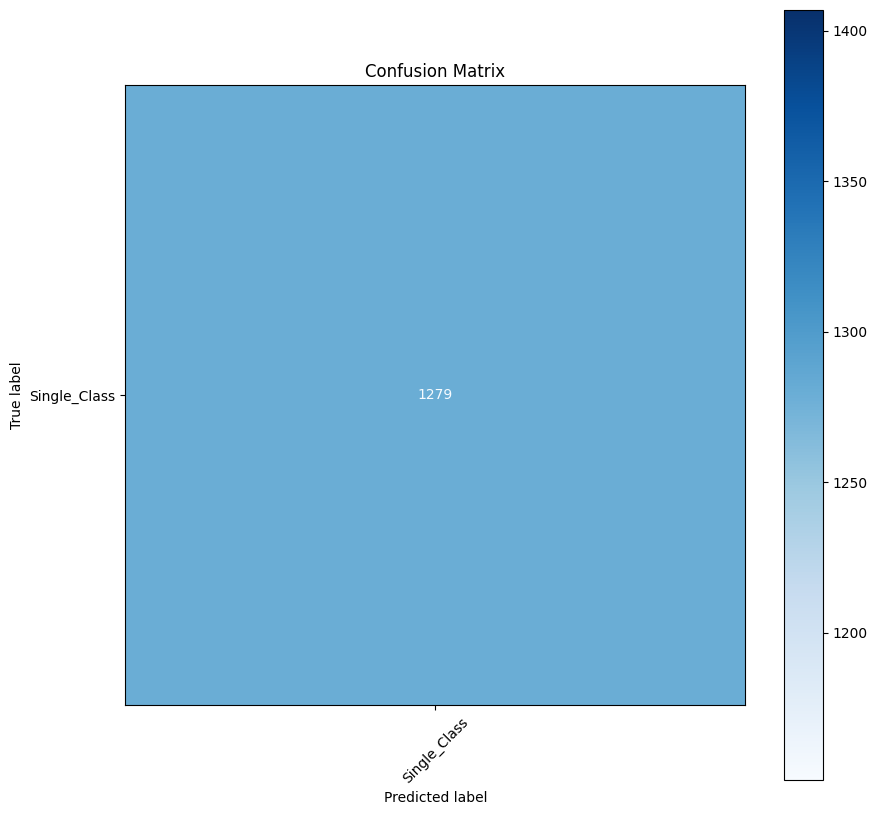

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

# Define class names (update to match the actual number of classes)
class_names = ['Single_Class']


# Plot the confusion matrix
plot_confusion_matrix(model, val_loader, class_names)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, confusion_matrix
)
import numpy as np
import torch

def get_overall_performance_metrics(model, dataloader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    # Core metrics
    accuracy = accuracy_score(y_true, y_pred)
    error_rate = 1 - accuracy
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    # Specificity calculation per class
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specificities = []
    for i in range(num_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity)
    specificity_macro = np.mean(specificities)

    # Print results
    print("\n Overall Performance Metrics:")
    print(f" Accuracy                : {accuracy:.4f}")
    print(f" Error Rate             : {error_rate:.4f}")
    print(f" Precision (macro avg)   : {precision:.4f}")
    print(f" Recall (macro avg)      : {recall:.4f}")
    print(f" F1-Score (macro avg)    : {f1:.4f}")
    print(f" Specificity (macro avg) : {specificity_macro:.4f}")
    print(f" Cohen’s Kappa Score     : {kappa:.4f}")
    print(f" Matthews Corr Coeff (MCC): {mcc:.4f}")

    return accuracy, error_rate, precision, recall, f1, specificity_macro, kappa, mcc

metrics = get_overall_performance_metrics(model, val_loader, num_classes=10)



 Overall Performance Metrics:
 Accuracy                : 1.0000
 Error Rate             : 0.0000
 Precision (macro avg)   : 1.0000
 Recall (macro avg)      : 1.0000
 F1-Score (macro avg)    : 1.0000
 Specificity (macro avg) : 0.9000
 Cohen’s Kappa Score     : nan
 Matthews Corr Coeff (MCC): 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
!pip install gradio


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import gradio as gr
import numpy as np # Import numpy for mean/std

# Define the TomatoCNN model class (copied from cell 5ed2c5a4 to ensure availability)
class TomatoCNN(nn.Module):
    def __init__(self, num_classes):
        super(TomatoCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   # (B, 3, 128, 128) -> (B, 32, 128, 128)
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (B, 32, 64, 64)

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (B, 64, 32, 32)

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (B, 128, 16, 16)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Correct MODEL_PATH to your saved model
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/data/numpy_arrays/tomato_cnn_model.pth"

# Initialize the model architecture with num_classes=1 (consistent with previous successful loading)
# Note: If you intend a multi-class classifier (e.g., 4 classes for Alzheimer's stages),
# you need to ensure your training data and model training supported that number of classes.
# The current notebook's training steps (e.g., from cell 3a31f897 output and a958873f)
# suggest it was treated as a single-class problem.
num_classes_for_model = 1 # Assuming the model was saved with 1 output class
model = TomatoCNN(num_classes=num_classes_for_model)

# Load the trained model's state_dict
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
model.eval()

# Image preprocessing function (matching training normalization from cell 7020d146)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # same size used in training
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Class labels (updated to reflect single class if model outputs 1 class)
# If the model was trained as a single-class classifier, it will always predict the first category.
# If a multi-class model is desired, review previous data loading and training cells.
classes = ["Detected Category"] # Placeholder for a single output category

# Prediction function
def predict_image(img):
    img = transform(img).unsqueeze(0)  # add batch dimension
    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        # For a single-class output, argmax will always be 0
        predicted_class_idx = torch.argmax(probs).item()
        predicted_class = classes[predicted_class_idx]

    # Return probabilities for a single class (will be ~1.0 for the first class)
    return {classes[0]: float(probs[0][0]) if probs.shape[1] > 0 else 1.0}

# Create Gradio interface
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=1), # Adjusted to 1 top class for single output
    title="🧠 Alzheimer’s MRI Classifier (Single-Class Model)",
    description="Upload an MRI scan. Note: This model appears to be trained as a single-class classifier. If multi-stage classification is intended, review prior data loading and training steps."
)

# Launch the app with a public link
interface.launch(share=True, debug=True)
